# Учимся работе с данными — от загрузки до моделирования

Датасет: [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data)

Целевая переменная `diagnosis`: **M** — злокачественная опухоль (malignant), **B** — доброкачественная (benign).

## Часть 1. EDA

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Загрузка данных

In [2]:
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'\nПропуски:\n{df.isna().sum().sum()}')
df.info()

Размер датасета: 569 строк, 32 столбцов

Пропуски:
0
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null 

### 2. Базовые статистики

In [4]:
feature_cols = [col for col in df.columns if col not in ('id', 'diagnosis')]
df[feature_cols].describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'})

,mean,median,std,min,max
radius_mean,14.127292,13.370000,3.524049,6.981000,28.11000
texture_mean,19.289649,18.840000,4.301036,9.710000,39.28000
perimeter_mean,91.969033,86.240000,24.298981,43.790000,188.50000
area_mean,654.889104,551.100000,351.914129,143.500000,2501.00000
smoothness_mean,0.096360,0.095870,0.014064,0.052630,0.16340
compactness_mean,0.104341,0.092630,0.052813,0.019380,0.34540
concavity_mean,0.088799,0.061540,0.079720,0.000000,0.42680
concave points_mean,0.048919,0.033500,0.038803,0.000000,0.20120
symmetry_mean,0.181162,0.179200,0.027414,0.106000,0.30400
fractal_dimension_mean,0.062798,0.061540,0.007060,0.049960,0.09744


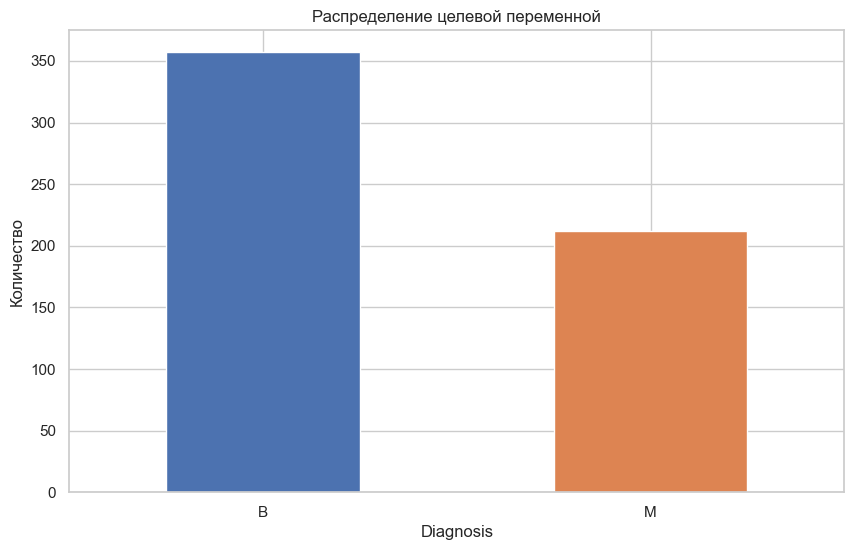

In [5]:
df['diagnosis'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'], rot=0)
plt.title('Распределение целевой переменной')
plt.xlabel('Diagnosis')
plt.ylabel('Количество')
plt.show()

### 3. Гистограммы признаков с группировкой по целевой переменной

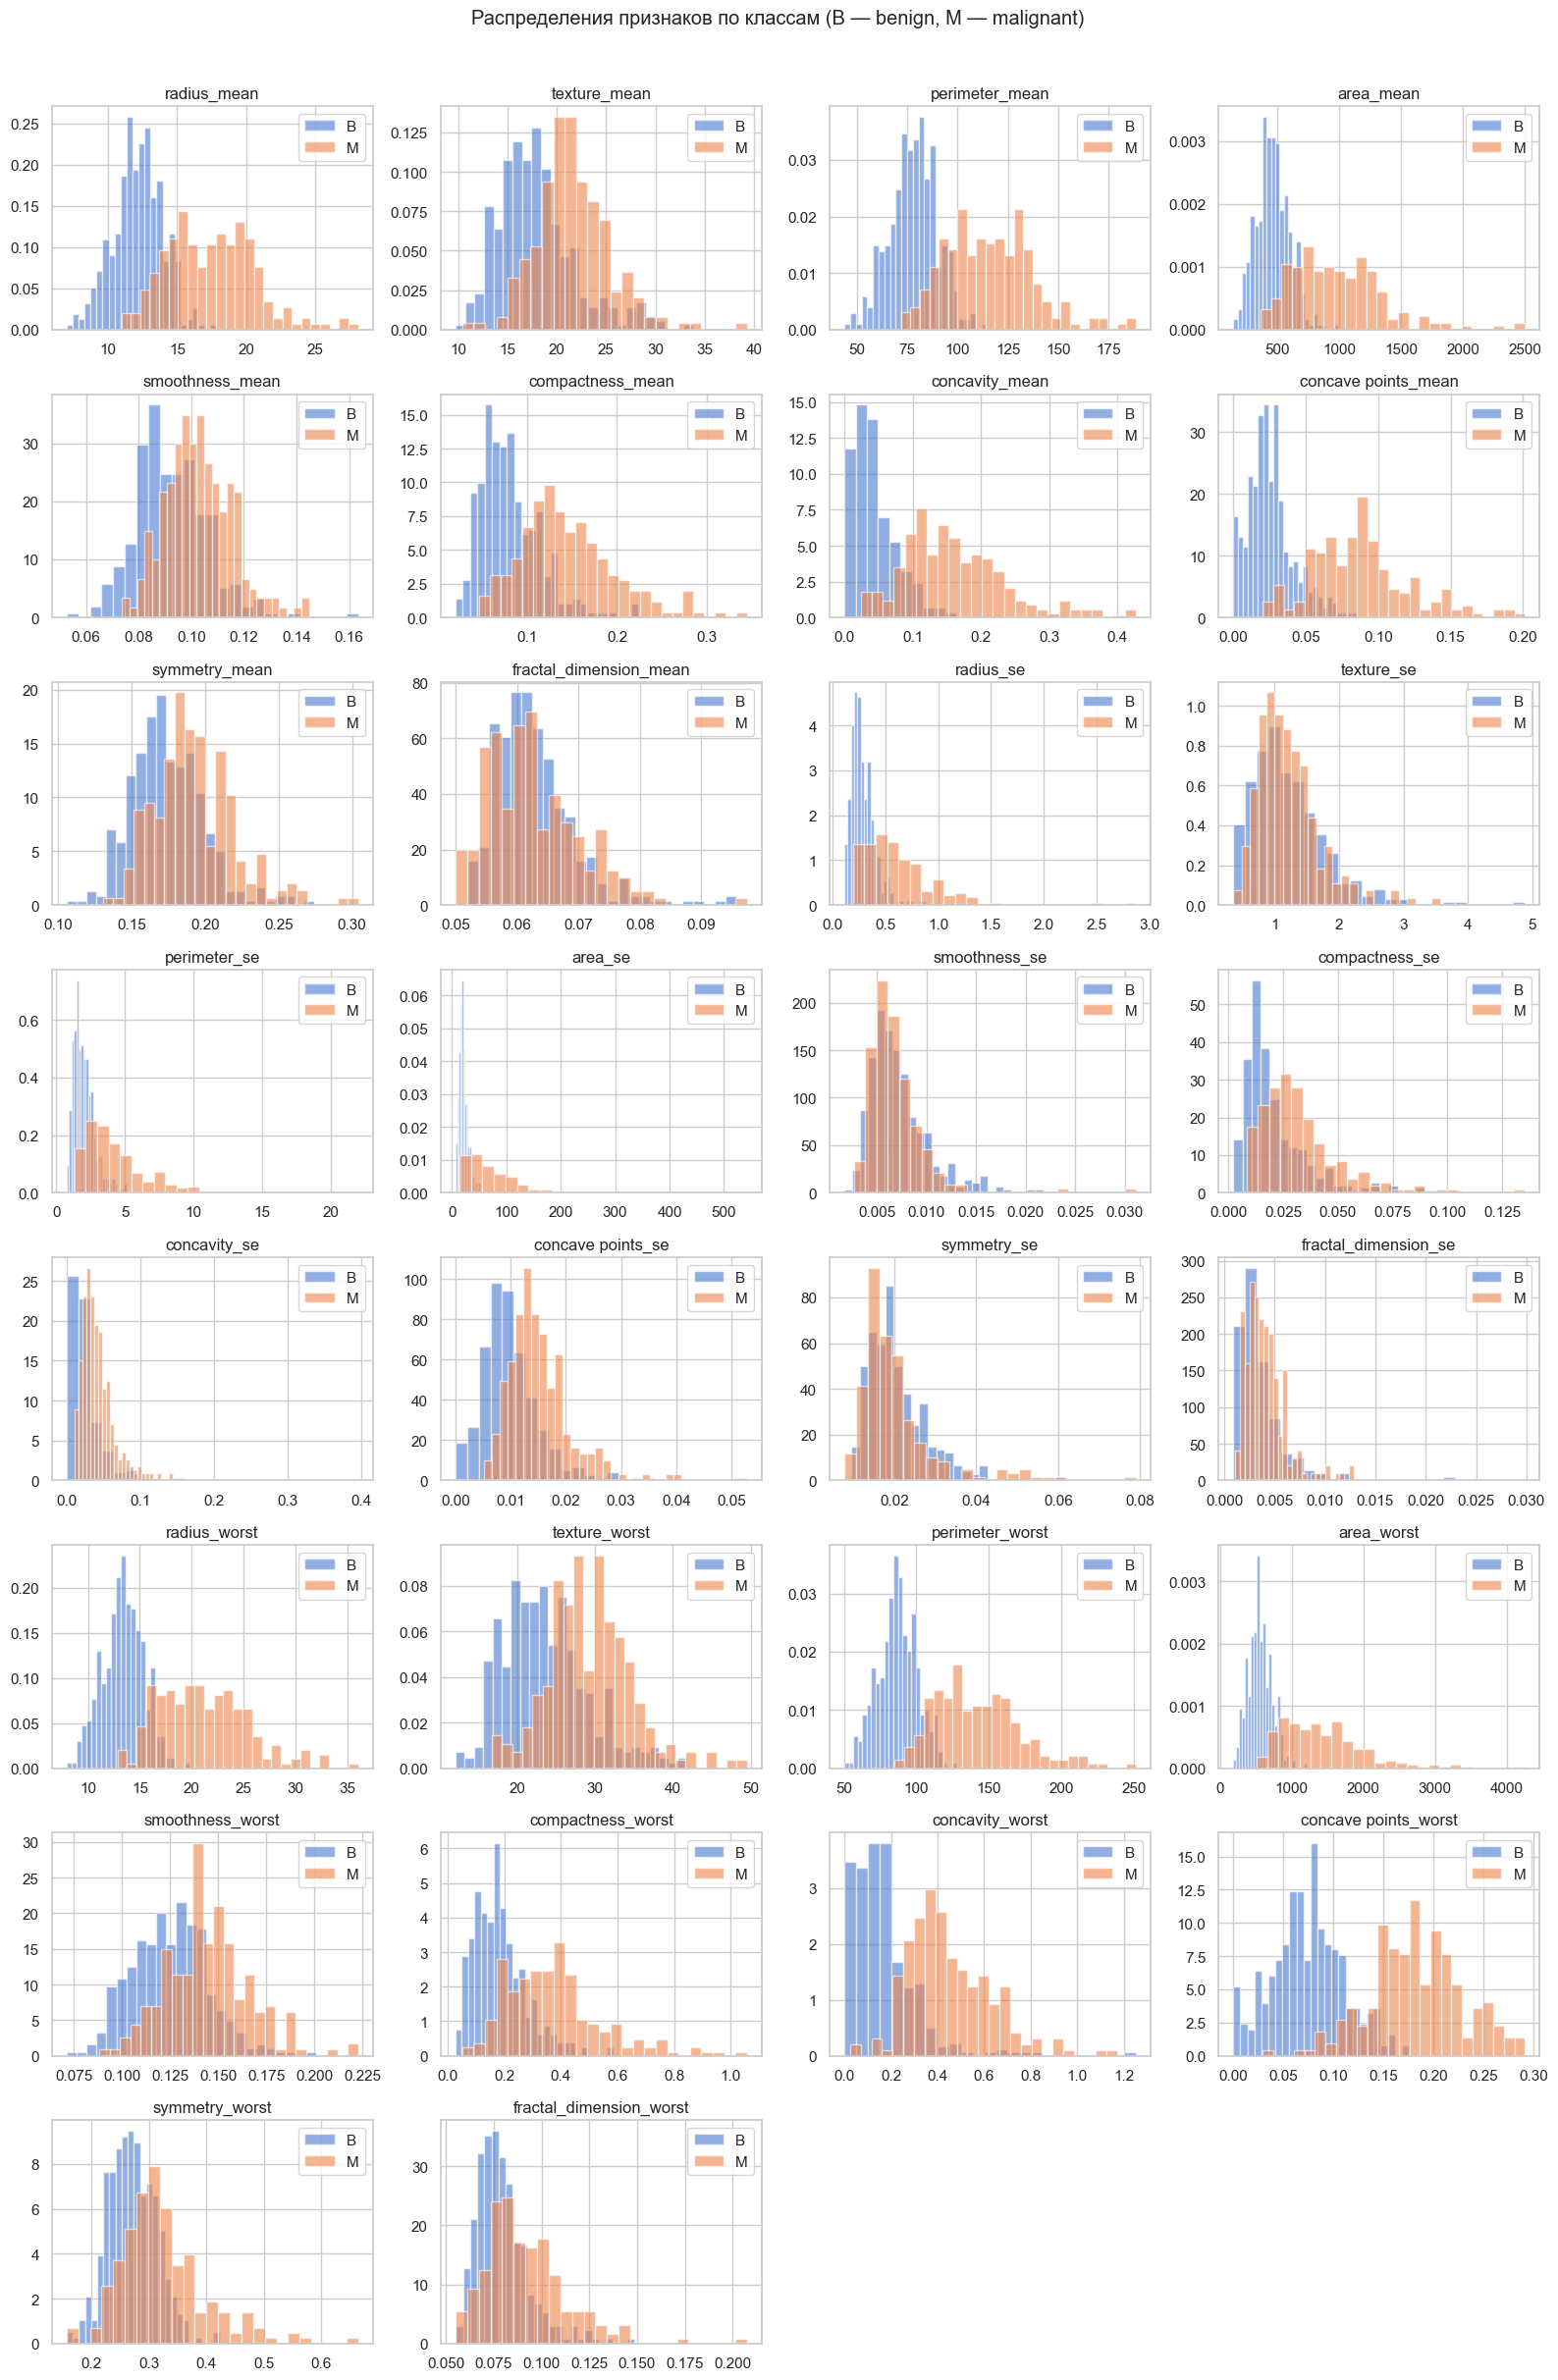

In [6]:
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    for diagnosis, group in df.groupby('diagnosis'):
        ax.hist(group[col], bins=25, alpha=0.6, label=diagnosis, density=True)
    ax.set_title(col)
    ax.legend()

for ax in axes[len(feature_cols):]:
    ax.axis('off')

plt.suptitle('Распределения признаков по классам (B — benign, M — malignant)', y=1.01)
plt.tight_layout()
plt.show()

### 4. Heatmap матрицы корреляций

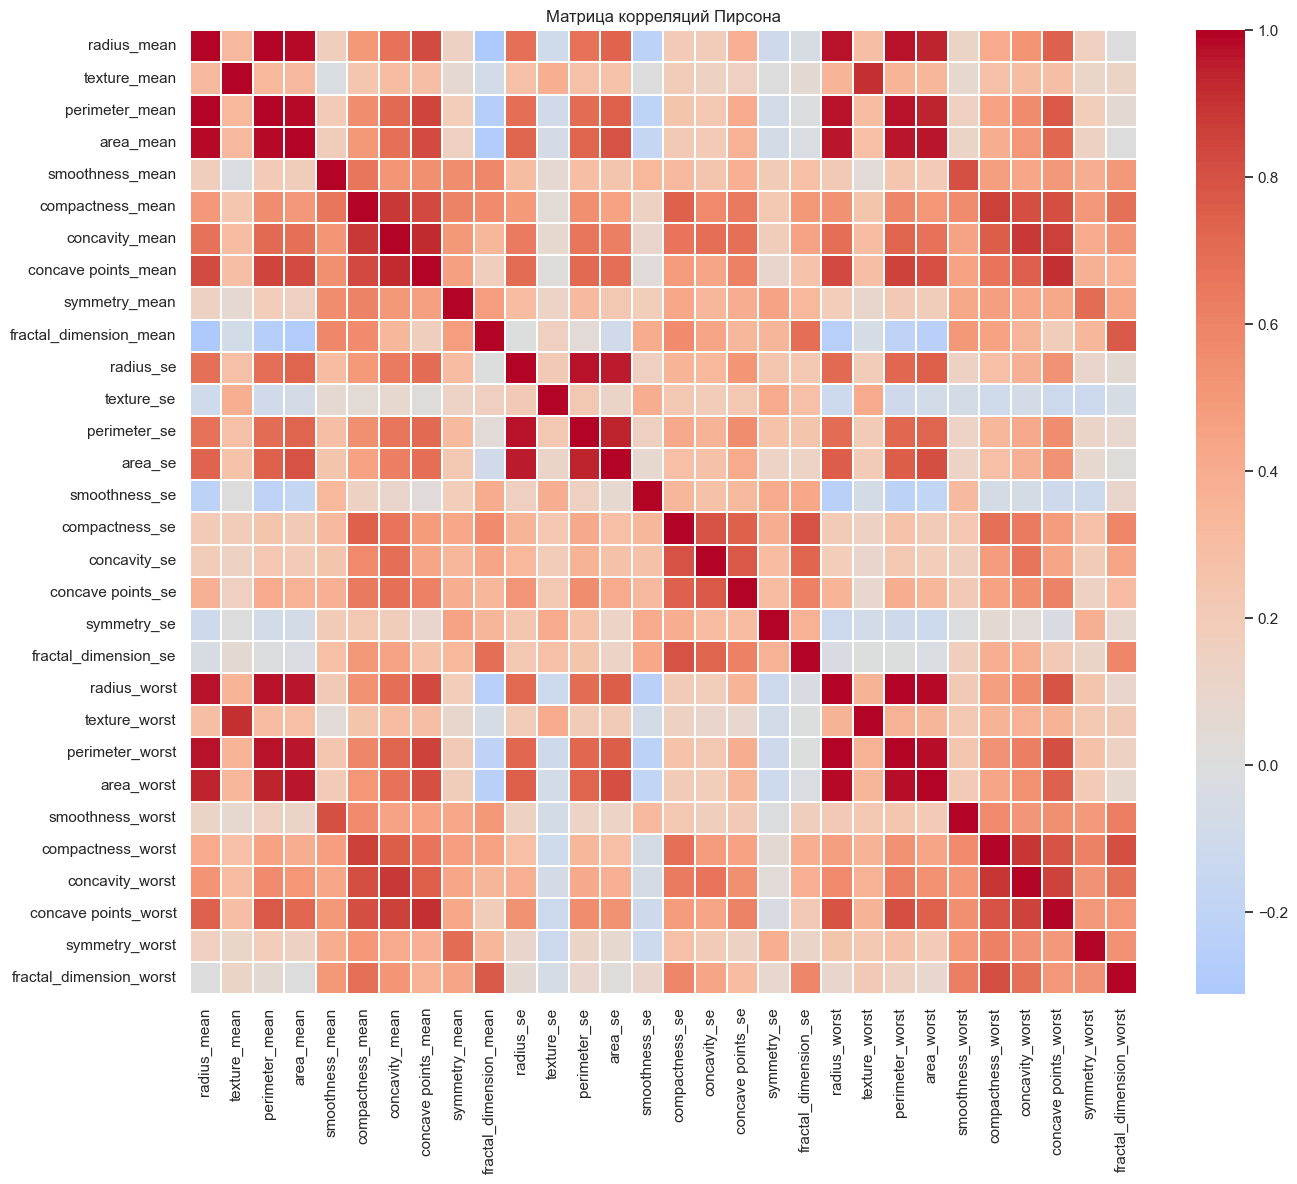

In [25]:
corr = df[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Матрица корреляций Пирсона')
plt.tight_layout()
plt.show()

In [26]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
)
strong_corr = corr_pairs[corr_pairs['correlation'].abs() > 0.85].sort_values('correlation', ascending=False)
print('Пары признаков с |корреляцией| > 0.85:')
strong_corr

Пары признаков с |корреляцией| > 0.85:


,feature_1,feature_2,correlation
2,radius_mean,perimeter_mean,0.997855
622,radius_worst,perimeter_worst,0.993708
3,radius_mean,area_mean,0.987357
63,perimeter_mean,area_mean,0.986507
623,radius_worst,area_worst,0.984015
683,perimeter_worst,area_worst,0.977578
312,radius_se,perimeter_se,0.972794
82,perimeter_mean,perimeter_worst,0.970387
20,radius_mean,radius_worst,0.969539
80,perimeter_mean,radius_worst,0.969476


**Вывод:** сильно скоррелированы признаки, описывающие размер и форму опухоли в разных вариациях (mean / worst):
- **radius, perimeter, area** — почти линейно связаны (периметр и площадь — функции радиуса, поэтому они коррелируют);
- **concavity_mean** и **concave points_mean**;
- аналогичные группы для `_worst` и частично `_se`.
То есть эти данные избыточны для построения логистической регрессии, но позволяет построить точечные графики коррелирующих признаков и их линейную связь

### 5. Scatterplot-ы для сильно скоррелированных признаков

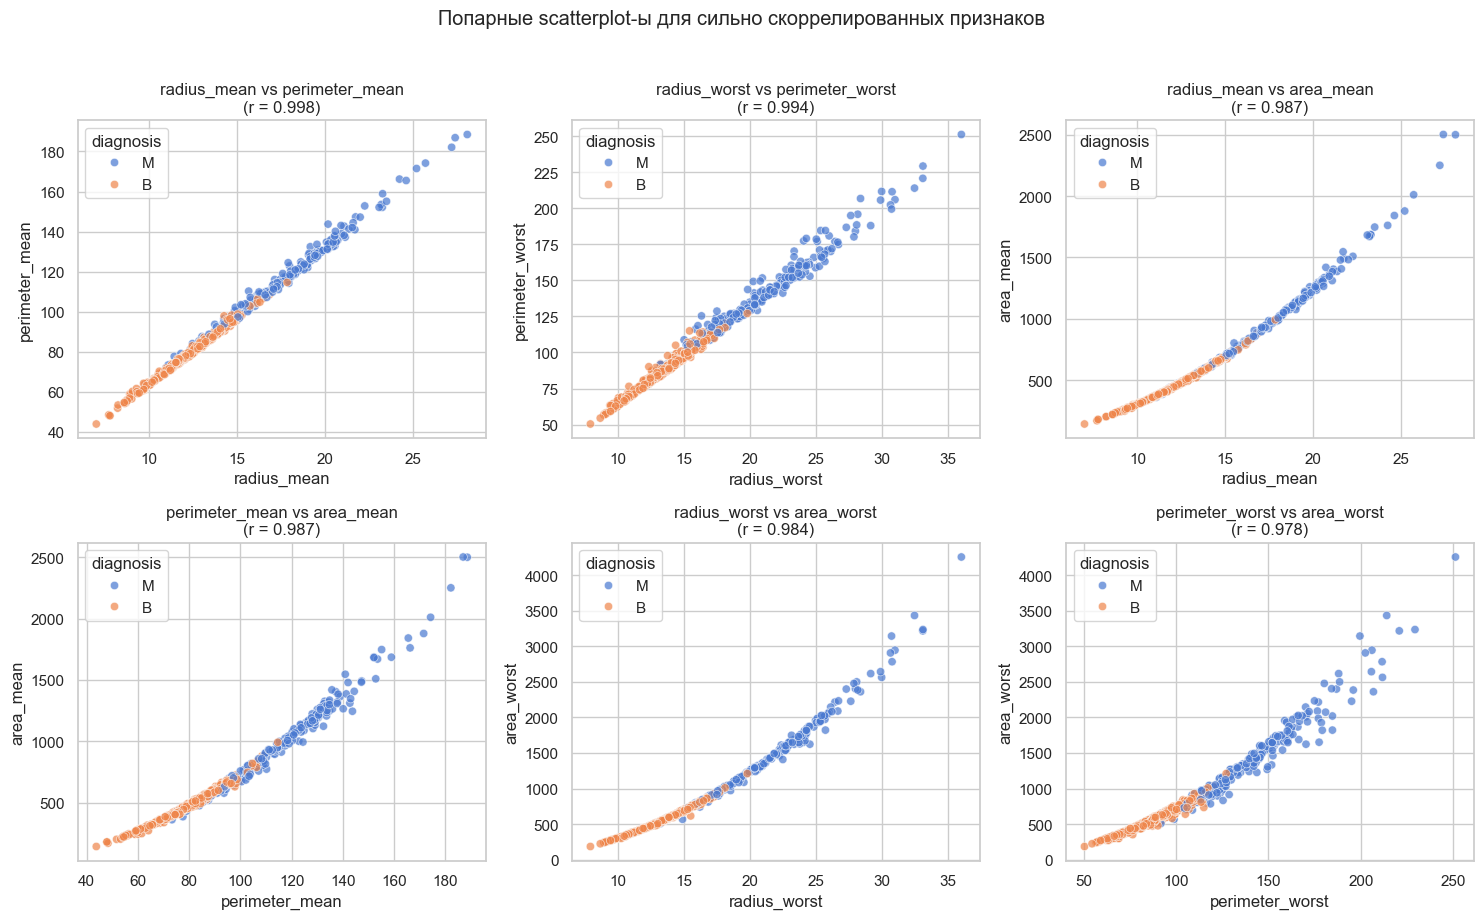

In [9]:
top_pairs = strong_corr.head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    f1, f2 = row['feature_1'], row['feature_2']
    sns.scatterplot(data=df, x=f1, y=f2, hue='diagnosis', alpha=0.7, ax=ax)
    ax.set_title(f'{f1} vs {f2}\n(r = {row["correlation"]:.3f})')

plt.suptitle('Попарные scatterplot-ы для сильно скоррелированных признаков', y=1.02)
plt.tight_layout()
plt.show()

На scatterplot-ах видна **почти линейная зависимость** (особенно для radius–perimeter–area - тех самых параметров сильно скорелированных по heatmap). При этом злокачественные опухоли (M) чаще занимают правую верхнюю часть облака — то есть они обычно больше доброкачественных, но говорить о том, что это основной признак нельзя (так как облака пересекаются по центру) .

### 6. Boxplot-ы по целевой переменной

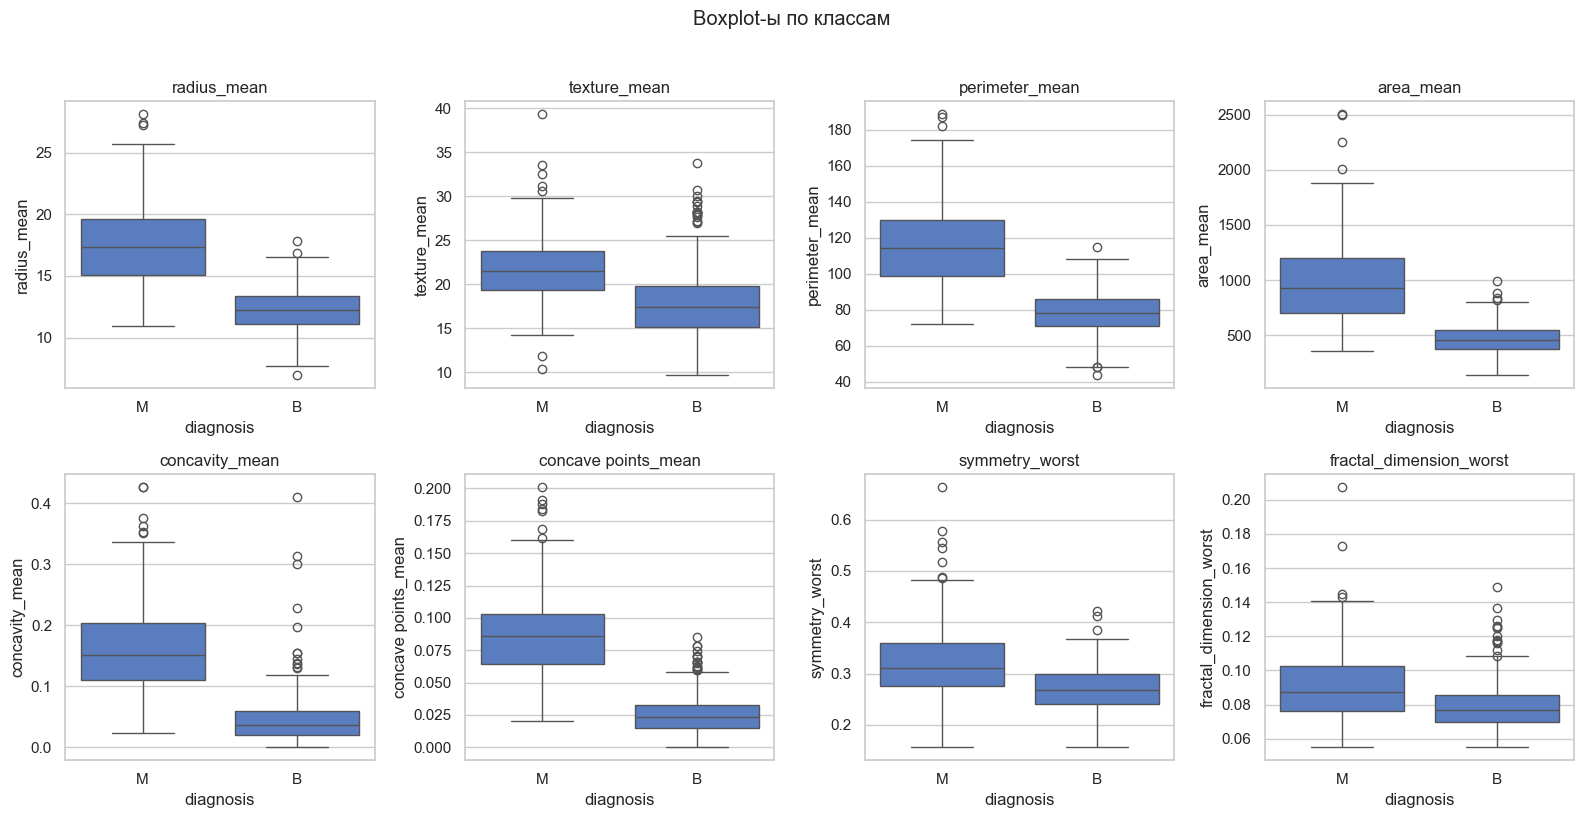

In [28]:
key_features = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'concavity_mean', 'concave points_mean', 'symmetry_worst', 'fractal_dimension_worst'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=ax)
    ax.set_title(col)

plt.suptitle('Boxplot-ы по классам', y=1.02)
plt.tight_layout()
plt.show()

Наиболее информативны признаки размера и формы ядра:
- `radius_mean`, `perimeter_mean`, `area_mean` — у злокачественных опухолей значения заметно выше;
- `concavity_mean`, `concave points_mean` — сильнее выражены впадины у класса злокачественных (М);
- `symmetry_worst`, `fractal_dimension_worst` — также показывают различимые медианы и разброс.

Признаки вроде `texture_mean` разделяют классы слабее — медианы близки, поэтому определить какая именно опухоль по текстуре без учета других признаков нельзя.

## Часть 2. Моделирование при помощи kNN

In [11]:
X = df[feature_cols]
y = (df['diagnosis'] == 'M').astype(int)  # 1 — malignant, 0 — benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Доля M в train: {y_train.mean():.3f}, в test: {y_test.mean():.3f}')

Train: (398, 30), Test: (171, 30)
Доля M в train: 0.372, в test: 0.374


### Стандартизация

Для kNN надо использовать евклидово расстояние между объектами. Перед расчетом надо стандартизировать признаки чтобы масштаб признака не влиял на результаты модели. 

In [12]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f'\n=== {name} ===')
    print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'F1-score:  {f1_score(y_true, y_pred):.4f}')
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f'ROC-AUC:   {auc:.4f}')
        return auc
    return None


def plot_roc(y_true, y_proba, label, ax):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})')
    return auc

### 3. kNN  с k=5 

In [13]:
knn_default = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()),
])

knn_default.fit(X_train, y_train)
y_pred_default = knn_default.predict(X_test)
y_proba_default = knn_default.predict_proba(X_test)[:, 1]

auc_default = evaluate_model('kNN (default, k=5)', y_test, y_pred_default, y_proba_default)
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_default))


=== kNN (default, k=5) ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-score:  0.9508
ROC-AUC:   0.9882

Confusion matrix:
[[107   0]
 [  6  58]]


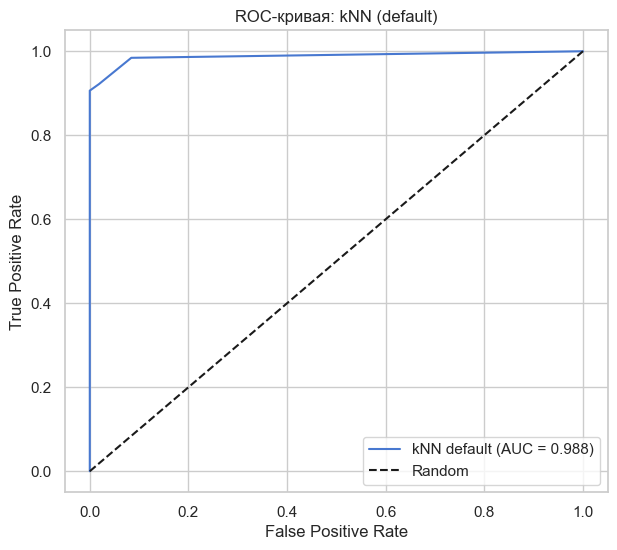

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc(y_test, y_proba_default, 'kNN default', ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая: kNN (default)')
ax.legend()
plt.show()

### 4. Подбор числа соседей на кросс-валидации

In [14]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()),
])

param_grid = {'knn__n_neighbors': list(range(1, 31))}
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f'Лучший k: {grid_search.best_params_["knn__n_neighbors"]}')
print(f'Лучший CV F1: {grid_search.best_score_:.4f}')

Лучший k: 5
Лучший CV F1: 0.9564


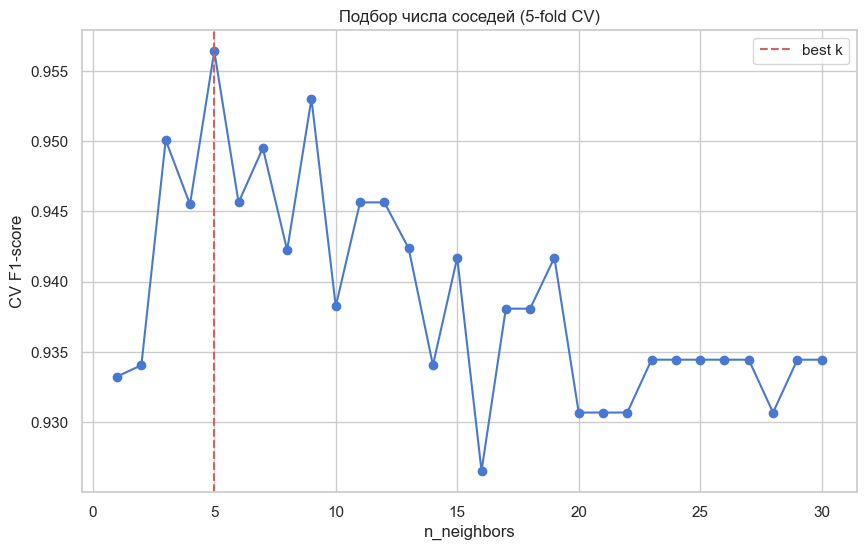

In [16]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['k'] = cv_results['param_knn__n_neighbors'].astype(int)

plt.plot(cv_results['k'], cv_results['mean_test_score'], marker='o')
plt.axvline(grid_search.best_params_['knn__n_neighbors'], color='r', linestyle='--', label='best k')
plt.xlabel('n_neighbors')
plt.ylabel('CV F1-score')
plt.title('Подбор числа соседей (5-fold CV)')
plt.legend()
plt.show()

In [17]:
knn_tuned = grid_search.best_estimator_
y_pred_tuned = knn_tuned.predict(X_test)
y_proba_tuned = knn_tuned.predict_proba(X_test)[:, 1]

auc_tuned = evaluate_model(
    f'kNN (tuned, k={grid_search.best_params_["knn__n_neighbors"]})',
    y_test, y_pred_tuned, y_proba_tuned
)
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_tuned))


=== kNN (tuned, k=5) ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-score:  0.9508
ROC-AUC:   0.9882

Confusion matrix:
[[107   0]
 [  6  58]]


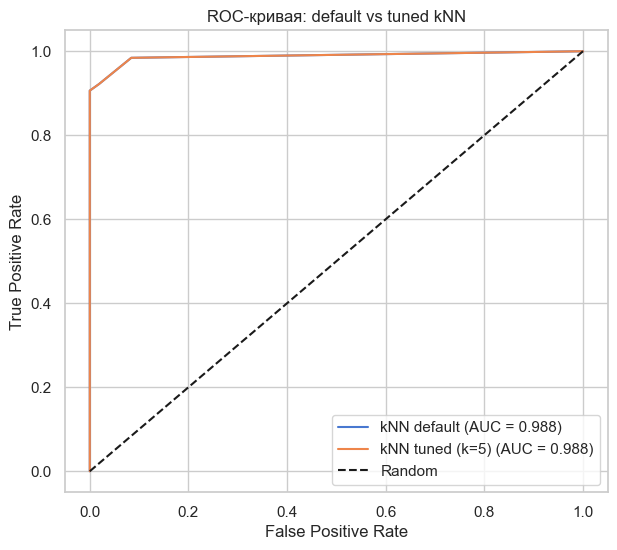


Улучшение ROC-AUC: 0.9882 → 0.9882 (+0.0000)


In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_roc(y_test, y_proba_default, 'kNN default', ax)
plot_roc(y_test, y_proba_tuned, f'kNN tuned (k={grid_search.best_params_["knn__n_neighbors"]})', ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая: default vs tuned kNN')
ax.legend()
plt.show()

print(f'\nУлучшение ROC-AUC: {auc_default:.4f} → {auc_tuned:.4f} ({auc_tuned - auc_default:+.4f})')

Подбор `k` на кросс-валидации обычно даёт небольшое, но стабильное улучшение: оптимальное число соседей балансирует между переобучением (малый k) и сглаживанием границ (большой k).

## Бонус. Логистическая регрессия

In [19]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

to_drop = set()
for _, row in strong_corr.iterrows():
    if abs(row['correlation']) > 0.85:
        to_drop.add(row['feature_2'])

reduced_features = [col for col in feature_cols if col not in to_drop]
print(f'Удалено признаков: {len(to_drop)}')
print(f'Осталось признаков: {len(reduced_features)}')
print('Удалённые:', sorted(to_drop))

Удалено признаков: 13
Осталось признаков: 17
Удалённые: ['area_mean', 'area_se', 'area_worst', 'compactness_worst', 'concave points_mean', 'concave points_worst', 'concavity_mean', 'concavity_worst', 'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_worst', 'texture_worst']


In [20]:
X_red = df[reduced_features]
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_red, y, test_size=0.3, random_state=42, stratify=y
)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10_000)),
])

lr_pipeline.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_pipeline.predict(X_test_lr)
y_proba_lr = lr_pipeline.predict_proba(X_test_lr)[:, 1]

auc_lr = evaluate_model('Logistic Regression (default)', y_test_lr, y_pred_lr, y_proba_lr)


=== Logistic Regression (default) ===
Accuracy:  0.9766
Precision: 1.0000
Recall:    0.9375
F1-score:  0.9677
ROC-AUC:   0.9972


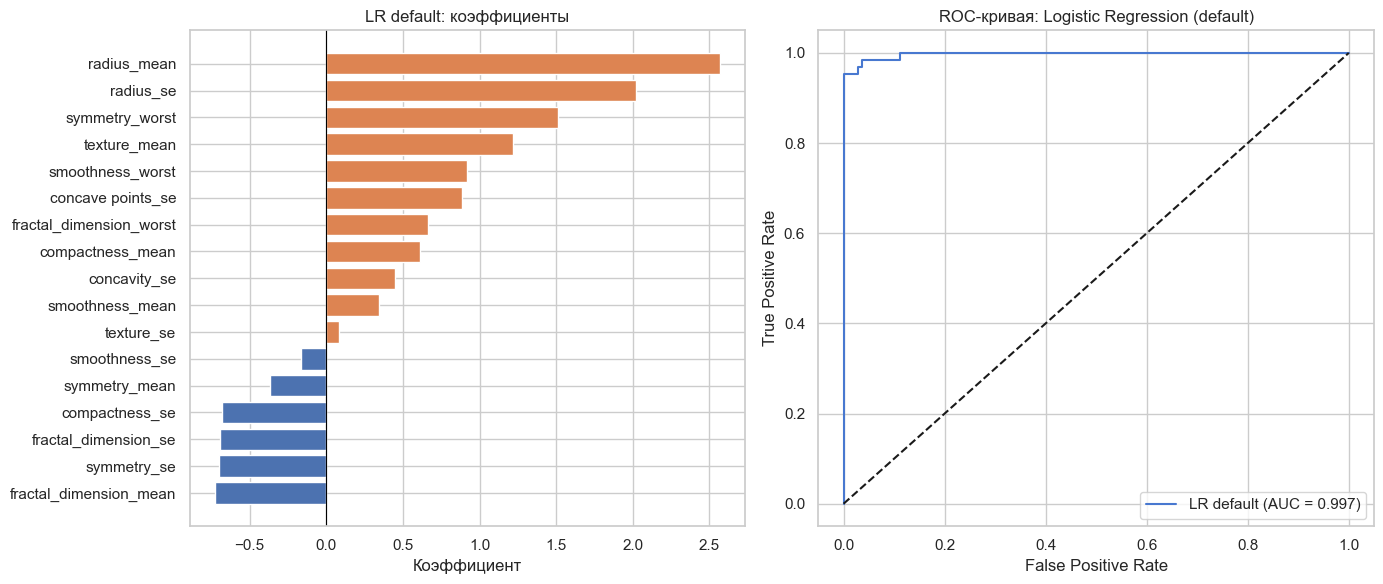

In [21]:
def plot_coefficients(model, feature_names, title, ax):
    coefs = model.named_steps['lr'].coef_[0]
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs}).sort_values('coefficient')
    colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
    ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Коэффициент')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_coefficients(lr_pipeline, reduced_features, 'LR default: коэффициенты', axes[0])

fpr, tpr, _ = roc_curve(y_test_lr, y_proba_lr)
axes[1].plot(fpr, tpr, label=f'LR default (AUC = {auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая: Logistic Regression (default)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [22]:
lr_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegressionCV(
        Cs=np.logspace(-3, 3, 20),
        cv=5,
        scoring='f1',
        max_iter=10_000,
    )),
])

lr_cv.fit(X_train_lr, y_train_lr)
best_C = lr_cv.named_steps['lr'].C_[0]
print(f'Лучший C: {best_C:.4f}')

y_pred_lr_cv = lr_cv.predict(X_test_lr)
y_proba_lr_cv = lr_cv.predict_proba(X_test_lr)[:, 1]
auc_lr_cv = evaluate_model(f'Logistic Regression (CV, C={best_C:.4f})', y_test_lr, y_pred_lr_cv, y_proba_lr_cv)

Лучший C: 0.1624

=== Logistic Regression (CV, C=0.1624) ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-score:  0.9508
ROC-AUC:   0.9969


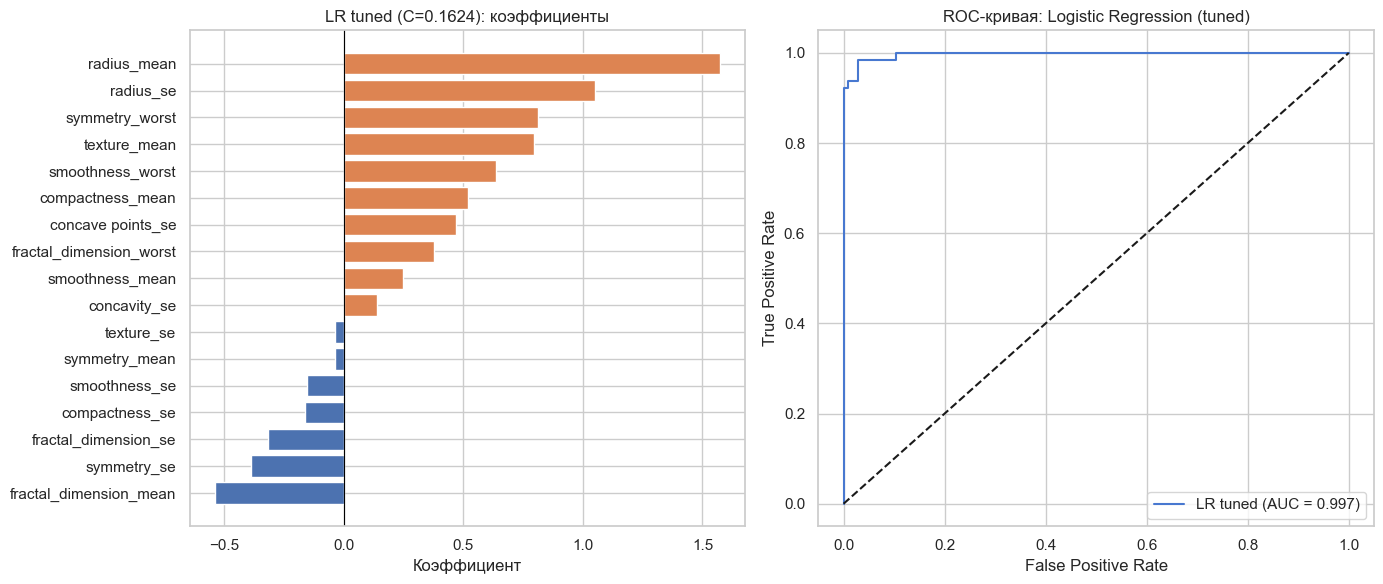

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_coefficients(lr_cv, reduced_features, f'LR tuned (C={best_C:.4f}): коэффициенты', axes[0])

fpr, tpr, _ = roc_curve(y_test_lr, y_proba_lr_cv)
axes[1].plot(fpr, tpr, label=f'LR tuned (AUC = {auc_lr_cv:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая: Logistic Regression (tuned)')
axes[1].legend()
plt.tight_layout()
plt.show()

### Сравнение моделей

**Выводы по логистической регрессии:**
- Положительные коэффициенты (например, у `radius_mean`, `concavity_mean`) увеличивают вероятность класса M — это согласуется с EDA.
- После удаления лишних признаков коэффициенты становятся более интерпретируемыми.

,Model,Accuracy,F1,ROC-AUC
2,LogReg default,0.976608,0.967742,0.997225
3,LogReg tuned (C=0.1624),0.964912,0.950820,0.996933
0,kNN default,0.964912,0.950820,0.988172
1,kNN tuned (k=5),0.964912,0.950820,0.988172


In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    'Model': [
        'kNN default',
        f'kNN tuned (k={grid_search.best_params_["knn__n_neighbors"]})',
        'LogReg default',
        f'LogReg tuned (C={best_C:.4f})',
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test_lr, y_pred_lr),
        accuracy_score(y_test_lr, y_pred_lr_cv),
    ],
    'F1': [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_tuned),
        f1_score(y_test_lr, y_pred_lr),
        f1_score(y_test_lr, y_pred_lr_cv),
    ],
    'ROC-AUC': [auc_default, auc_tuned, auc_lr, auc_lr_cv],
})
comparison.sort_values('ROC-AUC', ascending=False)

NameError: name 'pd' is not defined